# Bank Customer Churn Analysis & Predictive Modelling

### End-to-end case study

**Objective:** 
- To audit the data and pre-process it for modelling. 
- Do some EDA focused on understanding features for modelling.

**Insights we have from previously done SQL analysis:**

(these insights can be later tested as hypothesis once predictive modelling is built to verify the insights as well as predictions)

- Overall churn rate is 20.38% (1 in every 5 customers)
- Germany shows highest Churn. (32%) double compared to Spain & France
- Inactive customers churn at double rate than active customers.
- customers aged 46-65 show highest churn concentration.
- females exhibit higher churn.
- once a  customer complaints, it results in almost certain churn  (churn rate: 99.5%)

#

#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data Auditing & Validation

In [9]:
df= pd.read_csv("bank_customers.csv")
print(df.shape)
df.head()

(10000, 18)


,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfactionscore,cardtype,pointearned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,t,t,101348.88,t,t,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,f,t,112542.58,f,t,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,t,f,113931.57,t,t,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,f,f,93826.63,f,f,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,t,t,79084.10,f,f,5,GOLD,425


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rownumber          10000 non-null  int64  
 1   customerid         10000 non-null  int64  
 2   surname            10000 non-null  object 
 3   creditscore        10000 non-null  int64  
 4   geography          10000 non-null  object 
 5   gender             10000 non-null  object 
 6   age                10000 non-null  int64  
 7   tenure             10000 non-null  int64  
 8   balance            10000 non-null  float64
 9   numofproducts      10000 non-null  int64  
 10  hascrcard          10000 non-null  object 
 11  isactivemember     10000 non-null  object 
 12  estimatedsalary    10000 non-null  float64
 13  exited             10000 non-null  object 
 14  complain           10000 non-null  object 
 15  satisfactionscore  10000 non-null  int64  
 16  cardtype           1000

In [23]:
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rownumber,10000.000,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
customerid,10000.000,15690940.569,71936.186,15565701.000,15628528.250,15690738.000,15753233.750,15815690.000
creditscore,10000.000,650.529,96.653,350.000,584.000,652.000,718.000,850.000
age,10000.000,38.922,10.488,18.000,32.000,37.000,44.000,92.000
tenure,10000.000,5.013,2.892,0.000,3.000,5.000,7.000,10.000
balance,10000.000,76485.889,62397.405,0.000,0.000,97198.540,127644.240,250898.090
numofproducts,10000.000,1.530,0.582,1.000,1.000,1.000,2.000,4.000
estimatedsalary,10000.000,100090.240,57510.493,11.580,51002.110,100193.915,149388.247,199992.480
satisfactionscore,10000.000,3.014,1.406,1.000,2.000,3.000,4.000,5.000
pointearned,10000.000,606.515,225.925,119.000,410.000,605.000,801.000,1000.000


In [24]:
df.columns

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'complain',
       'satisfactionscore', 'cardtype', 'pointearned'],
      dtype='object')

In [ ]:
print(df.isnull().sum())
print("duplicate rows:" ,df.duplicated().sum())


rownumber            0
customerid           0
surname              0
creditscore          0
geography            0
gender               0
age                  0
tenure               0
balance              0
numofproducts        0
hascrcard            0
isactivemember       0
estimatedsalary      0
exited               0
complain             0
satisfactionscore    0
cardtype             0
pointearned          0
dtype: int64
duplicate rows: 0


In [29]:
print(df.nunique())

rownumber            10000
customerid           10000
surname               2932
creditscore            460
geography                3
gender                   2
age                     70
tenure                  11
balance               6382
numofproducts            4
hascrcard                2
isactivemember           2
estimatedsalary       9999
exited                   2
complain                 2
satisfactionscore        5
cardtype                 4
pointearned            785
dtype: int64


In [43]:
numbers=[
df.groupby('geography').aggregate({'customerid':'count'}),
df.groupby('gender').aggregate({'customerid':'count'}),
df.groupby('cardtype').aggregate({'customerid':'count'}),
df.groupby('isactivemember').aggregate({'customerid':'count'}),
df.groupby('hascrcard').aggregate({'customerid':'count'}),
df.groupby('numofproducts').aggregate({'customerid':'count'}),
df.groupby('complain').aggregate({'customerid':'count'}),
df.groupby('exited').aggregate({'customerid':'count'})]

for num in numbers:
    print(num)
    print()

           customerid
geography            
France           5014
Germany          2509
Spain            2477

        customerid
gender            
Female        4543
Male          5457

          customerid
cardtype            
DIAMOND         2507
GOLD            2502
PLATINUM        2495
SILVER          2496

                customerid
isactivemember            
f                     4849
t                     5151

           customerid
hascrcard            
f                2945
t                7055

               customerid
numofproducts            
1                    5084
2                    4590
3                     266
4                      60

          customerid
complain            
f               7956
t               2044

        customerid
exited            
f             7962
t             2038



### Data Pre-Processing Pipeline:

In [35]:
#grouping numeric & categorical columns:
numeric_cols= df.select_dtypes(include=np.number).columns
category_cols= df.select_dtypes(exclude=np.number).columns
print(numeric_cols)
print(category_cols)

Index(['rownumber', 'customerid', 'creditscore', 'age', 'tenure', 'balance',
       'numofproducts', 'estimatedsalary', 'satisfactionscore', 'pointearned'],
      dtype='object')
Index(['surname', 'geography', 'gender', 'hascrcard', 'isactivemember',
       'exited', 'complain', 'cardtype'],
      dtype='object')


In [44]:
#binary mapping:
binary_mapping = {'f': 0, 't': 1}
binary_cols = ['hascrcard', 'isactivemember', 'complain']
for col in binary_cols:
    df[col] = df[col].map(binary_mapping)

In [45]:
gender_mapping={'Female': 0, 'Male': 1}
df['gender']= df['gender'].map(gender_mapping)

In [49]:
#binary mapping target variable:
df['exited']= df['exited'].map({'f': 0, 't': 1})

In [48]:
#one-hot encoding for categorical columns:
dummy_variables= pd.get_dummies(df[['geography','cardtype']], dtype=int, drop_first=True)
dummy_variables.head(3)

,geography_Germany,geography_Spain,cardtype_GOLD,cardtype_PLATINUM,cardtype_SILVER
0,0,0,0,0,0
1,0,1,0,0,0
2,0,0,0,0,0


- dropping first categories because they're directly predictable if other categories are provided and we're using them as baseline categories i.e. geography_France and cardtype_DIAMOND.

In [50]:
df=pd.concat([df,dummy_variables], axis=1)
df.drop(columns=['rownumber', 'customerid', 'surname', 'geography', 'cardtype'], inplace=True)
df.head(3)

,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfactionscore,pointearned,geography_Germany,geography_Spain,cardtype_GOLD,cardtype_PLATINUM,cardtype_SILVER
0,619,0,42,2,0.000,1,1,1,101348.880,1,1,2,464,0,0,0,0,0
1,608,0,41,1,83807.860,1,0,1,112542.580,0,1,3,456,0,1,0,0,0
2,502,0,42,8,159660.800,3,1,0,113931.570,1,1,3,377,0,0,0,0,0


In [51]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   creditscore        10000 non-null  int64  
 1   gender             10000 non-null  int64  
 2   age                10000 non-null  int64  
 3   tenure             10000 non-null  int64  
 4   balance            10000 non-null  float64
 5   numofproducts      10000 non-null  int64  
 6   hascrcard          10000 non-null  int64  
 7   isactivemember     10000 non-null  int64  
 8   estimatedsalary    10000 non-null  float64
 9   exited             10000 non-null  int64  
 10  complain           10000 non-null  int64  
 11  satisfactionscore  10000 non-null  int64  
 12  pointearned        10000 non-null  int64  
 13  geography_Germany  10000 non-null  int64  
 14  geography_Spain    10000 non-null  int64  
 15  cardtype_GOLD      10000 non-null  int64  
 16  cardtype_PLATINUM  1000

,count,mean,std,min,25%,50%,75%,max
creditscore,10000.000,650.529,96.653,350.000,584.000,652.000,718.000,850.000
gender,10000.000,0.546,0.498,0.000,0.000,1.000,1.000,1.000
age,10000.000,38.922,10.488,18.000,32.000,37.000,44.000,92.000
tenure,10000.000,5.013,2.892,0.000,3.000,5.000,7.000,10.000
balance,10000.000,76485.889,62397.405,0.000,0.000,97198.540,127644.240,250898.090
numofproducts,10000.000,1.530,0.582,1.000,1.000,1.000,2.000,4.000
hascrcard,10000.000,0.706,0.456,0.000,0.000,1.000,1.000,1.000
isactivemember,10000.000,0.515,0.500,0.000,0.000,1.000,1.000,1.000
estimatedsalary,10000.000,100090.240,57510.493,11.580,51002.110,100193.915,149388.247,199992.480
exited,10000.000,0.204,0.403,0.000,0.000,0.000,0.000,1.000


In [52]:
#correlation:
df.corr(numeric_only=True)['exited'].sort_values(ascending=False)

exited               1.000
complain             0.996
age                  0.285
geography_Germany    0.173
balance              0.119
estimatedsalary      0.012
cardtype_PLATINUM   -0.000
cardtype_SILVER     -0.004
pointearned         -0.005
satisfactionscore   -0.006
hascrcard           -0.007
tenure              -0.014
cardtype_GOLD       -0.016
creditscore         -0.027
numofproducts       -0.048
geography_Spain     -0.053
gender              -0.106
isactivemember      -0.156
Name: exited, dtype: float64

- we see that complain is having highest correlation with churn i.e. 'exited' column. 
so for this, can make two models one with complain as a feature and other without to make comparisons. 
- Germany having higher corr validates previous SQL analysis findings of it being most churned customers' region. 
- satisfaction score doesn't have much corr. 
- gender,age, balance & activity could be other impacting features.

(corr only defines linear relations)

#

##### EDA for identifying columns that can be featured, mainly for categories like balance, credit-score, age

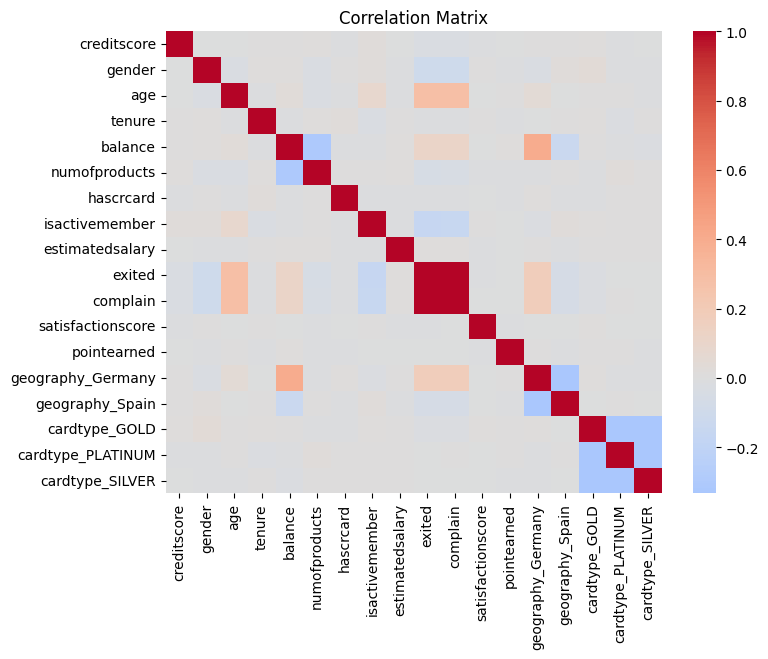

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

- Target Distribution

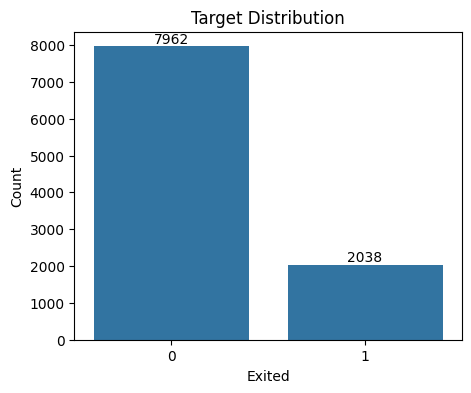

exited
0   79.620
1   20.380
Name: proportion, dtype: float64


In [66]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='exited', data=df)
plt.title("Target Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.show()
print(df['exited'].value_counts(normalize=True)*100)

- Numerical Distributions

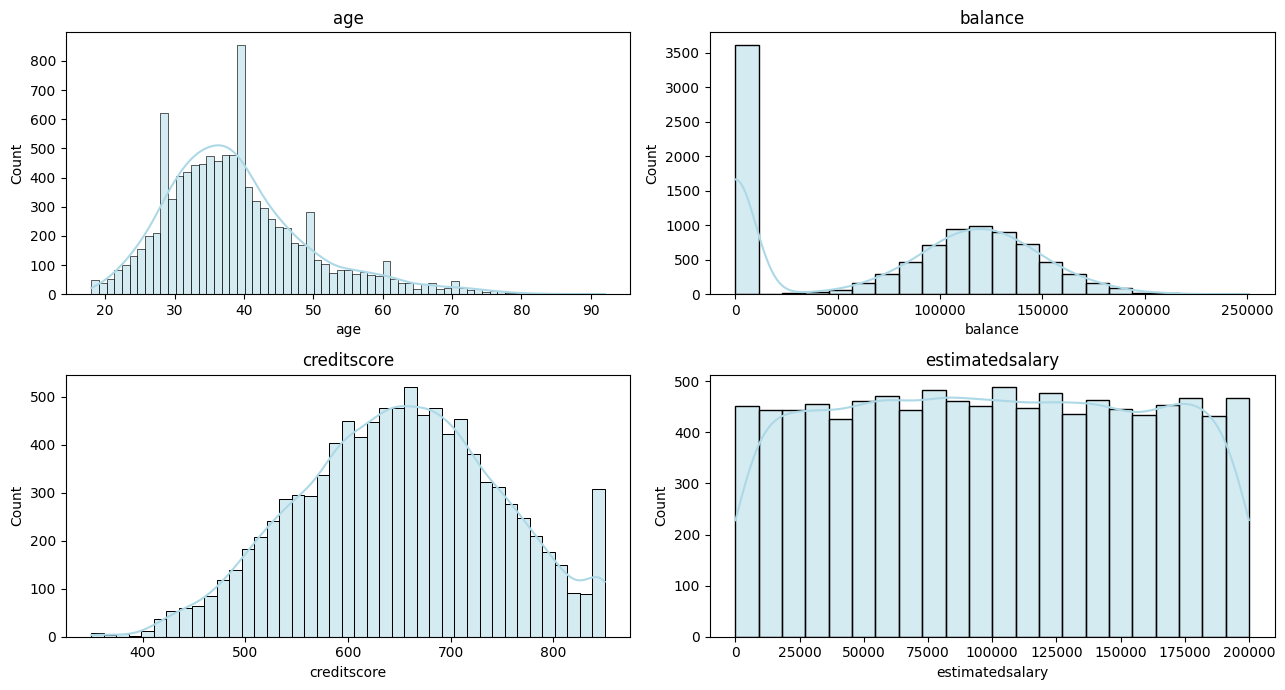

In [71]:
cols = ['age','balance','creditscore','estimatedsalary']
fig, axes = plt.subplots(2,2, figsize=(13,7))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()

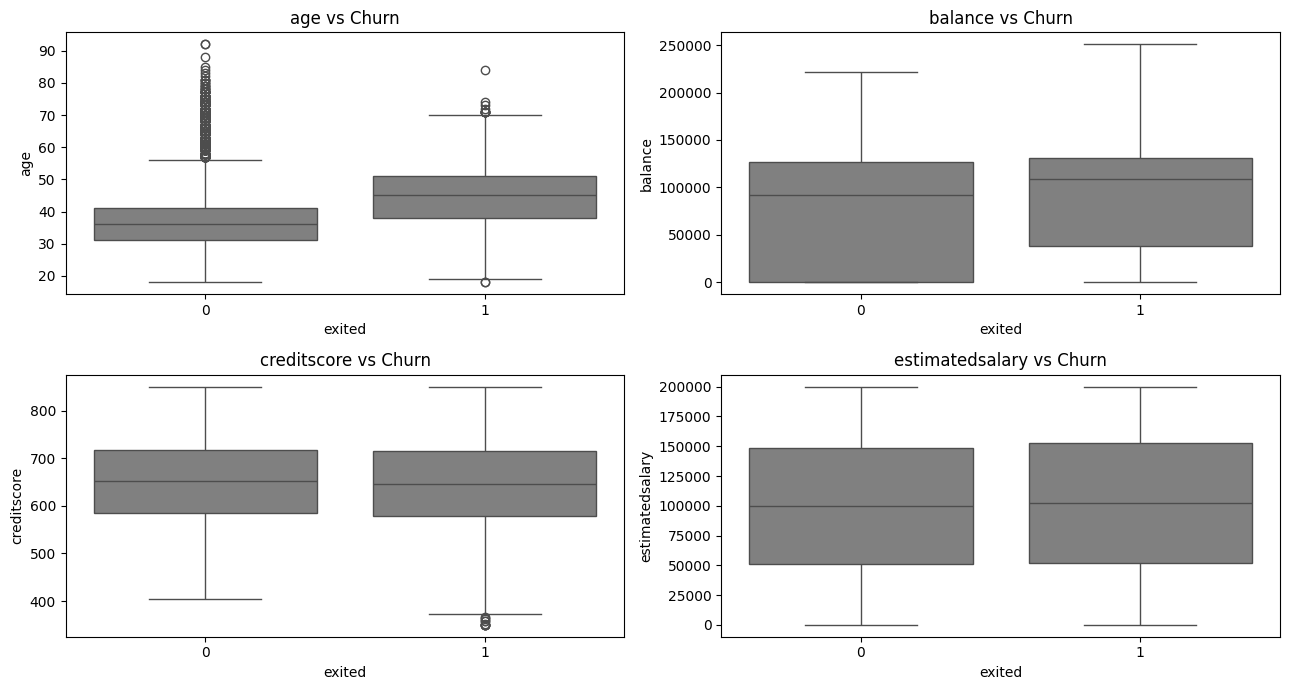

In [69]:
features= ['age', 'balance', 'creditscore', 'estimatedsalary']
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df,x='exited',y=feature,ax=ax, color='grey')
    ax.set_title(f'{feature} vs Churn')

plt.tight_layout()
plt.show()

1. Age vs Churn:
- churned customers probably have higher median age. 
- same observation was found in SQL analysis where customers in age segment 46-65 had churned most. 
- so age is an informative feature.

2. Balance vs Churn:
- churned customers have slightly higher median balance, but not clear distinction, there is some overlap.

3. credit score & estimated salary:
- they're comparatively weak predictors of churn since their medians and distributions are almost identical.

In [73]:
df.to_csv("processed_data.csv", index=False)